In [1]:
#%config InlineBackend.figure_formats=['svg']
from os import listdir
import numpy as np

from ExistingAlgorithms.Plot import plot_1D, plot_traces

from AutoencoderAPI.utils.files import load_mean_std
from AutoencoderAPI.utils.compare import compare
from AutoencoderAPI.utils.clustering.kernelDensity import kernel_density
from AutoencoderAPI.utils.clustering.densityGaussianMixture import density_gaussianMixture
from AutoencoderAPI.loadAutoencoder import loadAutoencoder

from ExistingAlgorithms.MaxValue import max_value
from ExistingAlgorithms.Area import area
from ExistingAlgorithms.SklearnAvailable import dimension_reduction

from sklearn.decomposition import PCA, KernelPCA, NMF
from sklearn.manifold import Isomap, TSNE

In [2]:
signal_size = 30_000
certain_clusters = 3
selected_dB = 12.04#9.05#18.97#
path_dB = 'Datasets/SNSPD/Paderborn/db_shuffled.npy'
path_test = 'Datasets/SNSPD/Paderborn/data test/'
path_train = 'Datasets/SNSPD/Paderborn/data train/'
path_model = 'grid-search-SNSPD param 4/run 09/fold 0'
path_save = f'MetricLog/Metric_SNSPD_{selected_dB}dB'
mean, std = load_mean_std(path_model)
print(mean, std)

X_test = []
X_train = []
number_file_test = len(listdir(path_test)) 
number_file_train = len(listdir(path_train))
dB = np.load(path_dB)

for file_number in range(number_file_test):
    
    if dB[file_number] == selected_dB:
        data_temp = np.load(f"{path_test}/TracesNr{file_number}.npy").reshape(-1,signal_size)
        data_temp = data_temp[:, 3250:4500]
    
        X_test.append(data_temp)

for file_number in range(number_file_test, number_file_train):
    
    if dB[file_number] == selected_dB:
        data_temp = np.load(f"{path_train}/TracesNr{file_number}.npy").reshape(-1,signal_size)
        data_temp = data_temp[:, 3250:4500]

        X_train.append(data_temp)

X_train = -1*np.concatenate(X_train)
X_train = (X_train - mean)/std
X_train = X_train[np.min(X_train, axis=1) < -0.55]
X_train = X_train[np.max(X_train, axis=1) > 0]

X_test = -1*np.concatenate(X_test)
X_test = (X_test - mean)/std
X_test = X_test[np.min(X_test, axis=1) < -0.55]
X_test = X_test[np.max(X_test, axis=1) > 0]

8287.182046417778 18042.082022959665


In [12]:
"""
signal_size = 30_000
certain_clusters = 3
path_test = 'Datasets/SNSPD/Paderborn/data test/'
path_train = 'Datasets/SNSPD/Paderborn/data train/'
path_model = 'grid-search-SNSPD param 4/run 09/fold 0'
path_save = 'MetricLog/Metric_SNSPD'
mean, std = load_mean_std(path_model)
print(mean, std)

X_test = -1 * np.concatenate([np.load(f"{path_test}{fileName}").reshape(-1,signal_size)[::15, 3250:4500] for fileName in listdir(path_test)])#[::2]
X_train = -1 * np.concatenate([np.load(f"{path_train}{fileName}").reshape(-1,signal_size)[::15, 3250:4500] for fileName in listdir(path_train)])

X_test = (X_test - mean) / std
X_train = (X_train - mean) / std

#init_len = len(X_test)
#X_test = X_test[np.min(X_test, axis=1) < -0.5]
X_train = X_train[np.max(X_train, axis=1) > 0]
X_test = X_test[np.max(X_test, axis=1) > 0]
X_train = X_train[np.min(X_train, axis=1) < -1.6]
X_test = X_test[np.min(X_test, axis=1) <  -1.6]
#zeros = init_len - len(X_test)
"""

'\nsignal_size = 30_000\ncertain_clusters = 3\npath_test = \'Datasets/SNSPD/Paderborn/data test/\'\npath_train = \'Datasets/SNSPD/Paderborn/data train/\'\npath_model = \'grid-search-SNSPD param 4/run 09/fold 0\'\npath_save = \'MetricLog/Metric_SNSPD\'\nmean, std = load_mean_std(path_model)\nprint(mean, std)\n\nX_test = -1 * np.concatenate([np.load(f"{path_test}{fileName}").reshape(-1,signal_size)[::15, 3250:4500] for fileName in listdir(path_test)])#[::2]\nX_train = -1 * np.concatenate([np.load(f"{path_train}{fileName}").reshape(-1,signal_size)[::15, 3250:4500] for fileName in listdir(path_train)])\n\nX_test = (X_test - mean) / std\nX_train = (X_train - mean) / std\n\n#init_len = len(X_test)\n#X_test = X_test[np.min(X_test, axis=1) < -0.5]\nX_train = X_train[np.max(X_train, axis=1) > 0]\nX_test = X_test[np.max(X_test, axis=1) > 0]\nX_train = X_train[np.min(X_train, axis=1) < -1.6]\nX_test = X_test[np.min(X_test, axis=1) <  -1.6]\n#zeros = init_len - len(X_test)\n'

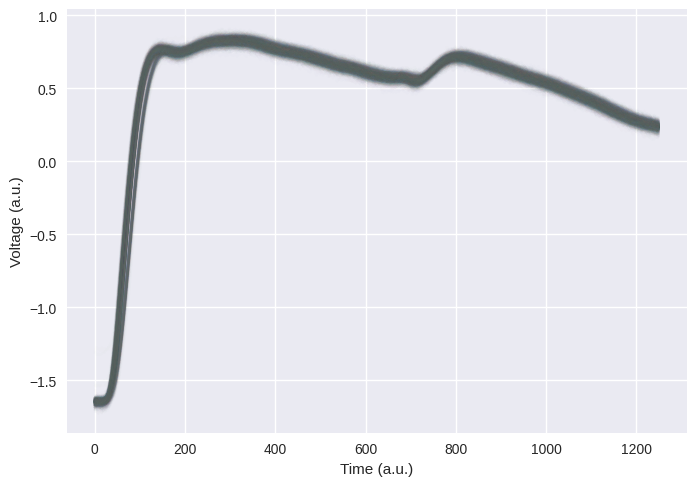

In [13]:
plot_traces(np.copy(X_test))

### Max Value

In [14]:
X_i_MAX, X_r_MAX, X_l_MAX = max_value(np.copy(X_test), filter=True)

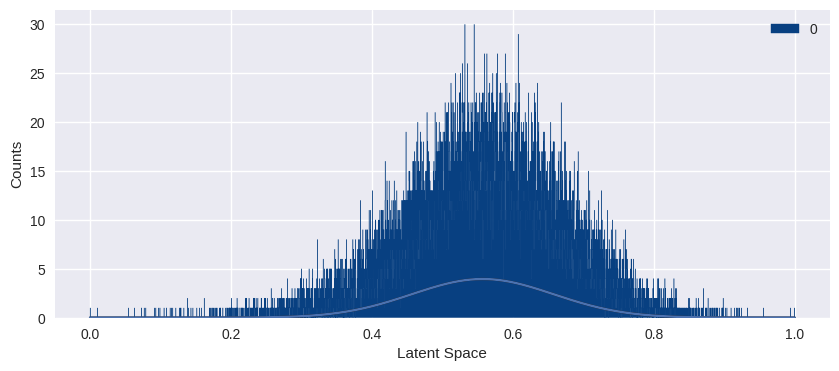

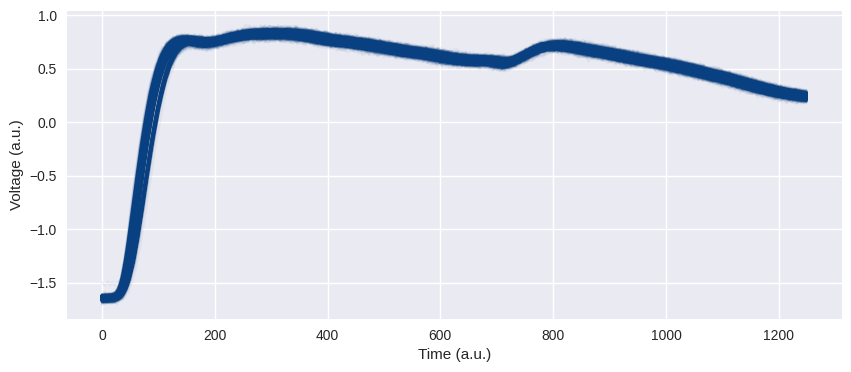

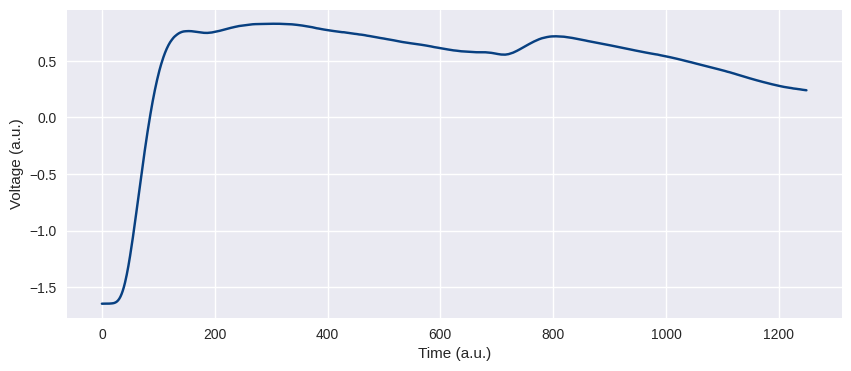

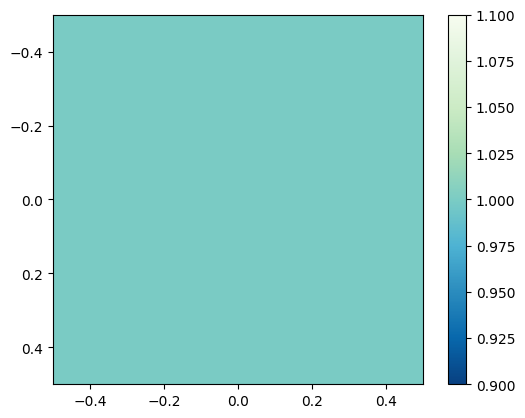

In [15]:
kd = density_gaussianMixture(X_l_MAX, 
                            bw = [0.02], 
                            min_cluster_prob = 0.1,
                            bins_plot = 5000,
                            flip = False, 
                            skip = 0)
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))
kd.plot_traces_average(np.copy(X_test))
kd.plot_cross_talk()
X_l_MAX = kd.normalize_latent(X_l_MAX, certain_clusters)

### Area

In [16]:
X_i_AREA, X_r_AREA, X_l_AREA = area(np.copy(X_test), filter=True, threshold_cst=0)

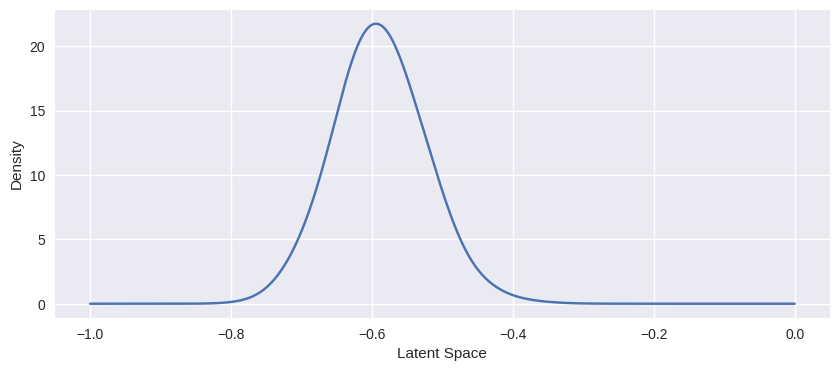

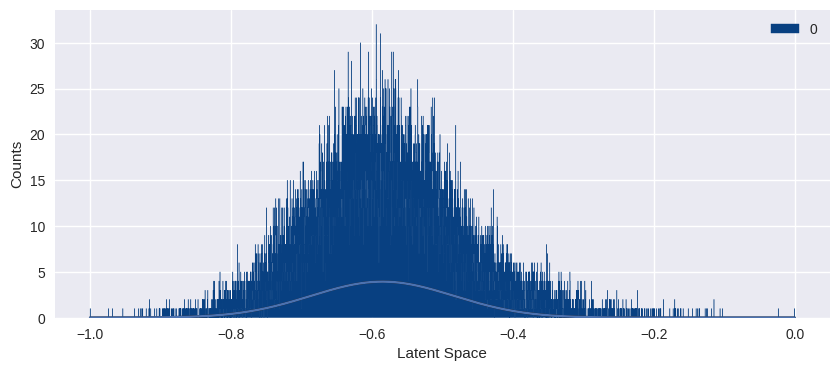

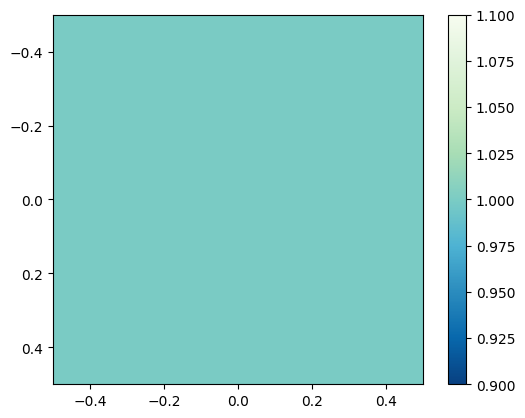

In [17]:
kd = density_gaussianMixture(X_l_AREA, 
                                bw = [0.0268], 
                                min_cluster_prob = 0.1,
                                bins_plot = 5000,
                                flip = True, 
                                skip = 1)
kd.plot_density()
kd.plot_cluster()
#kd.plot_traces(np.copy(X_test))
kd.plot_cross_talk()
X_l_AREA = kd.normalize_latent(X_l_AREA, certain_clusters)

### Principal Component Analysis (PCA)

In [3]:
X_i_PCA, X_l_PCA = dimension_reduction(np.copy(X_train),np.copy(X_test), path_save, PCA, n_components=1) 

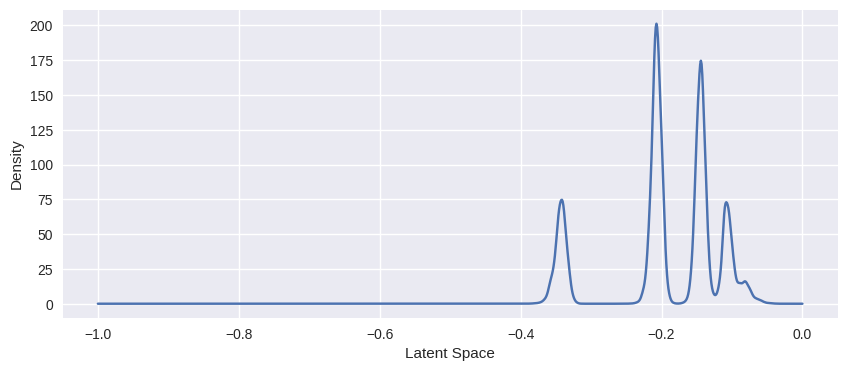

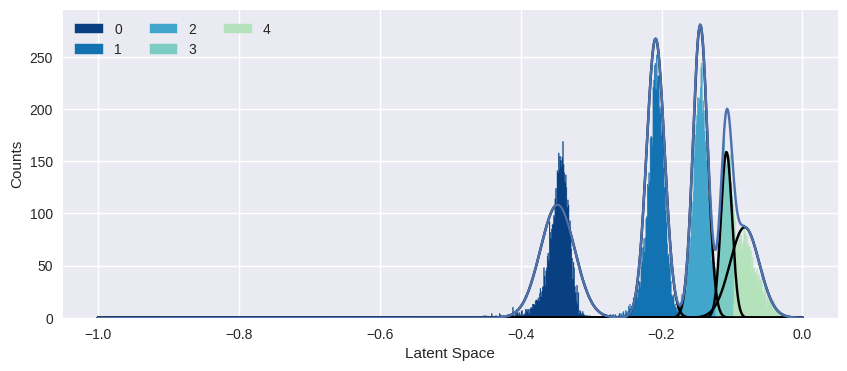

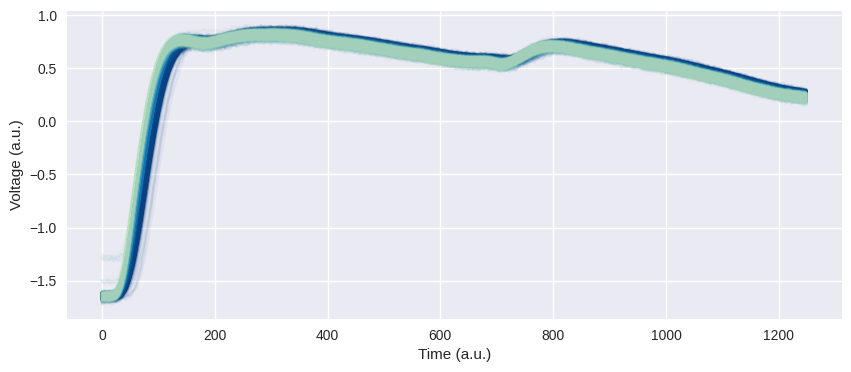

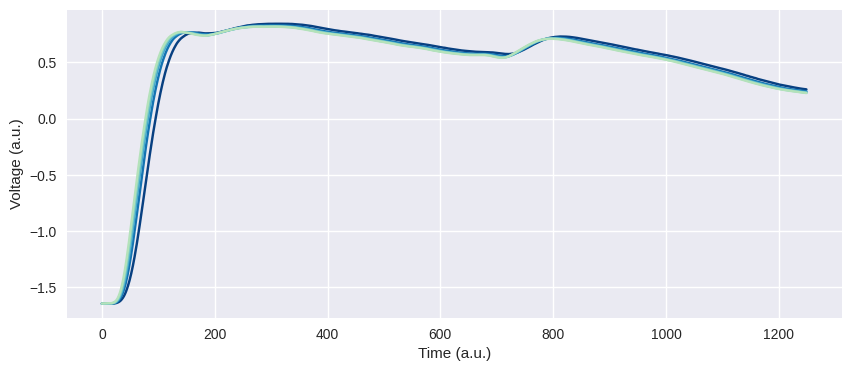

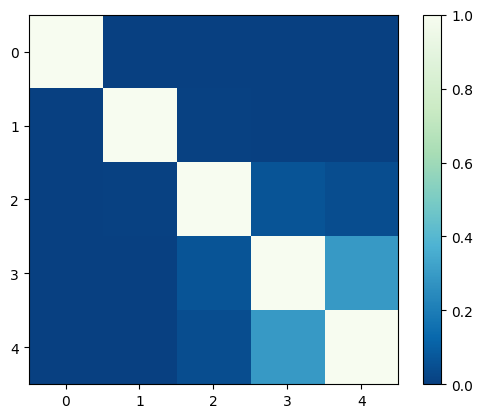

In [4]:
kd = density_gaussianMixture(X_l_PCA,
                            bw =  [0.0025], #[0.029],
                            min_cluster_prob = 1,
                            bins_plot = 1000,
                            flip = True,
                            skip = 0)
kd.plot_density()
kd.plot_cluster(30)
kd.plot_traces(np.copy(X_test))
kd.plot_traces_average(np.copy(X_test))
kd.plot_cross_talk()
#kd.confidence(zeros)
X_l_PCA = kd.normalize_latent(X_l_PCA, certain_clusters)

### Kernel PCA (Polynomial)

In [20]:
X_i_KPCA_P, X_l_KPCA_P = dimension_reduction(np.copy(X_train),np.copy(X_test), path_save,KernelPCA,n_components=1, kernel="poly", fit_inverse_transform=True)

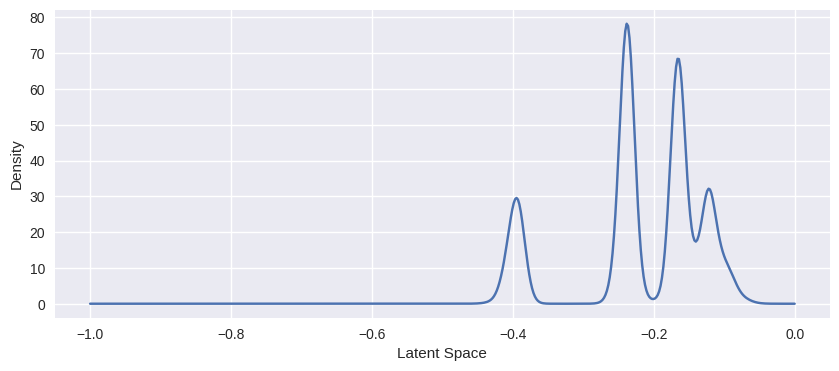

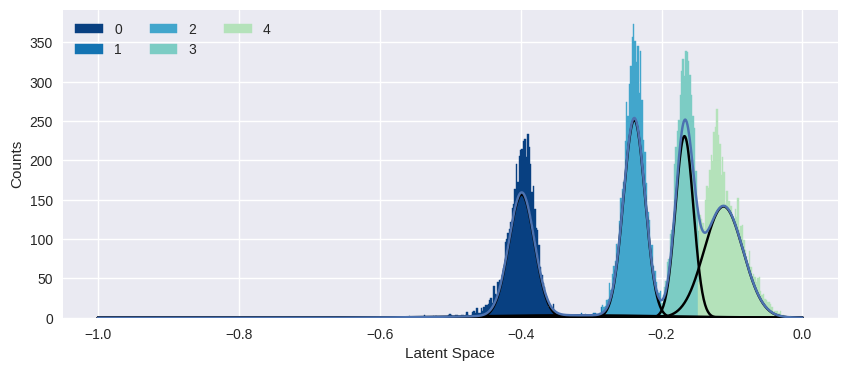

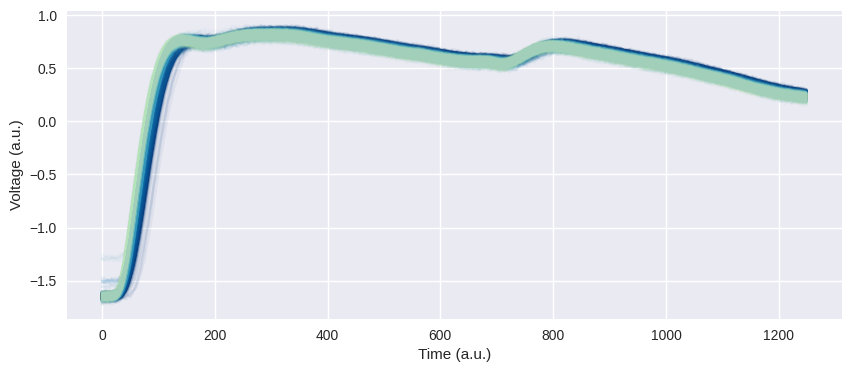

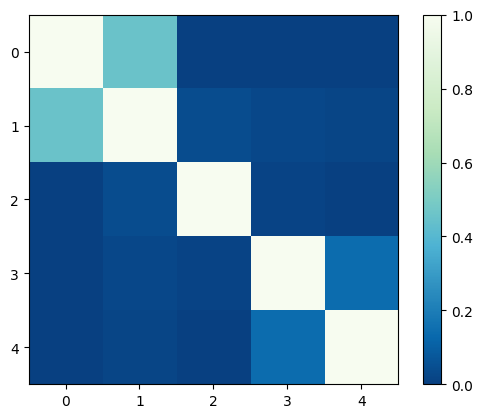

In [21]:
kd = density_gaussianMixture(X_l_KPCA_P, 
                                bw = [0.008],
                                min_cluster_prob = 0.02,
                                bins_plot = 500,
                                flip = True, 
                                skip = 0)
kd.plot_density()
kd.plot_cluster(35)
kd.plot_traces(np.copy(X_test))
kd.plot_cross_talk()
#kd.confidence(zeros)
X_l_KPCA_P = kd.normalize_latent(X_l_KPCA_P, certain_clusters)

### Kernel PCA (Radial basis function)

In [22]:
X_i_KPCA_RBF, X_l_KPCA_RBF = dimension_reduction(np.copy(X_train),np.copy(X_test), path_save,KernelPCA,n_components=1,kernel="rbf",gamma=0.02, fit_inverse_transform=True)

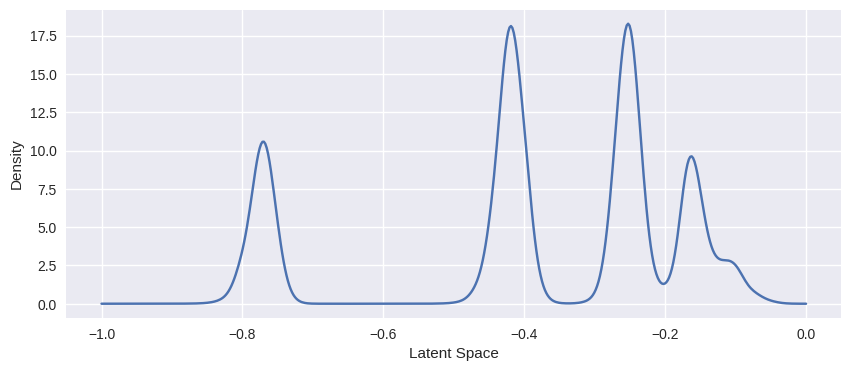

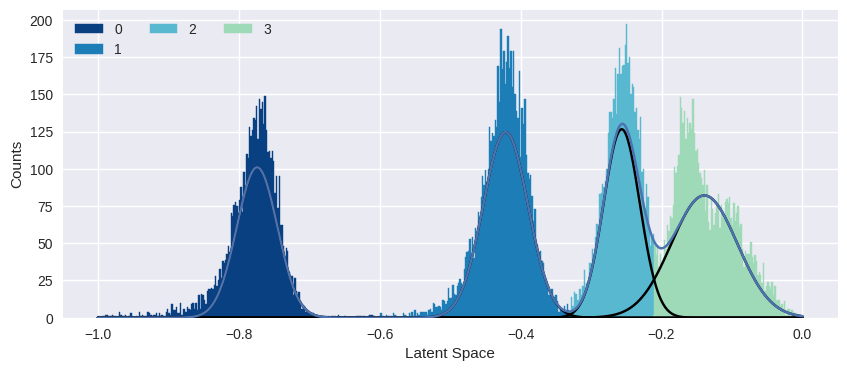

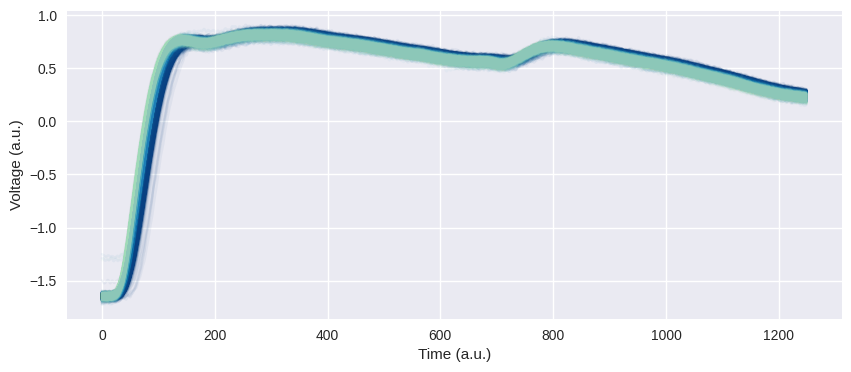

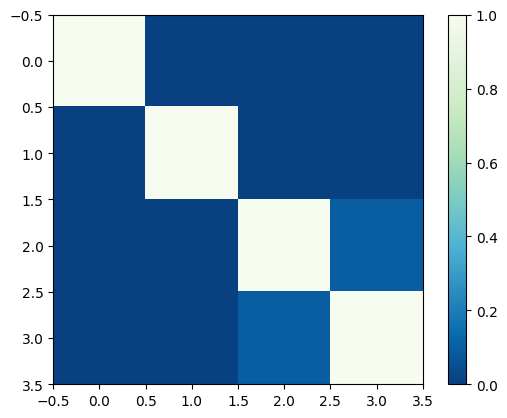

In [23]:
kd = density_gaussianMixture(X_l_KPCA_RBF, 
                                bw = [0.01],
                                min_cluster_prob = 0.02,
                                bins_plot = 500,
                                flip = True, 
                                skip = 0)
kd.plot_density()
kd.plot_cluster(35)
kd.plot_traces(np.copy(X_test))
kd.plot_cross_talk()
#kd.confidence(zeros)
X_l_KPCA_RBF = kd.normalize_latent(X_l_KPCA_RBF, certain_clusters)

### Kernel PCA (Sigmoid)

In [24]:
X_i_KPCA_S, X_l_KPCA_S = dimension_reduction(np.copy(X_train),np.copy(X_test), path_save,KernelPCA,n_components=1,kernel="sigmoid",gamma=0.02, fit_inverse_transform=True)

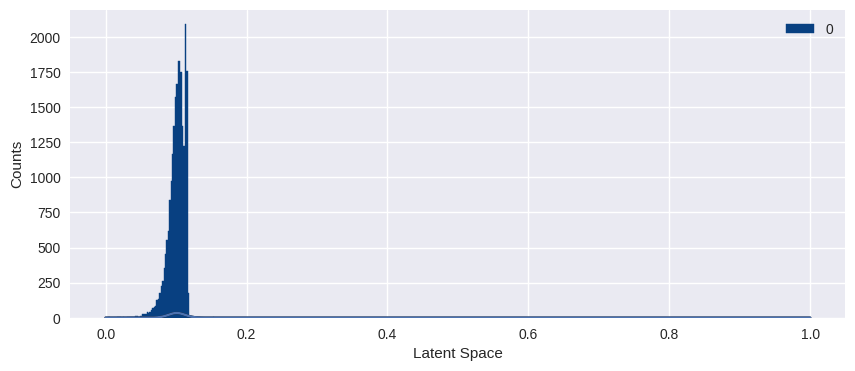

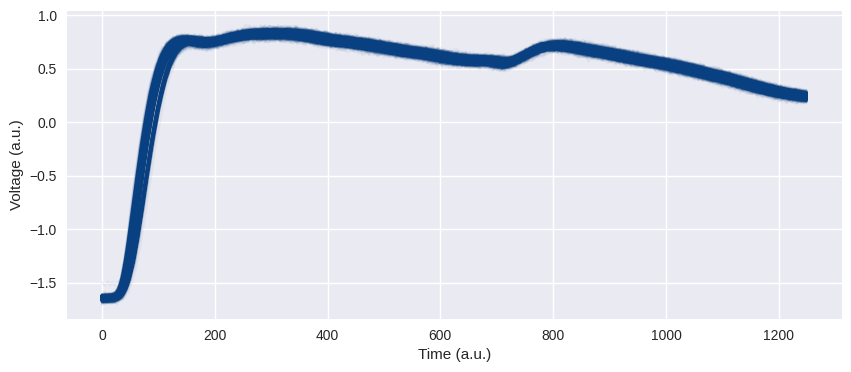

In [25]:
kd = density_gaussianMixture(X_l_KPCA_S, 
                                bw = [0.01],
                                min_cluster_prob = 0.02,
                                bins_plot = 500,
                                flip = False, 
                                skip = 0)
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))
#kd.confidence(zeros)
X_l_KPCA_S = kd.normalize_latent(X_l_KPCA_S, certain_clusters)

### Kernel PCA (Cosine)

In [26]:
X_i_KPCA_C, X_l_KPCA_C = dimension_reduction(np.copy(X_train),np.copy(X_test), path_save,KernelPCA,n_components=1,kernel="cosine",gamma=0.02, fit_inverse_transform=True)

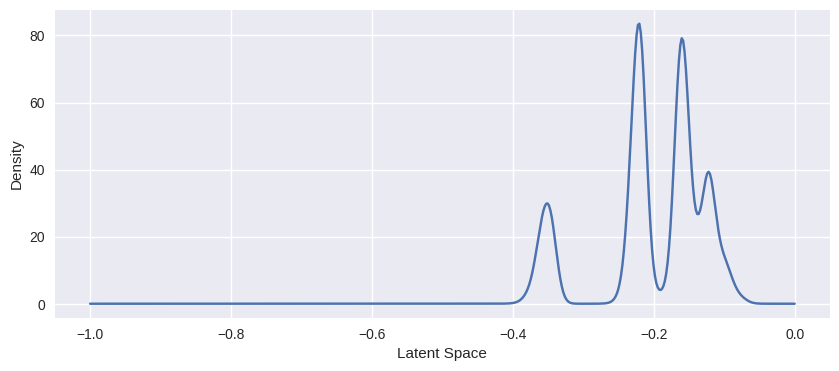

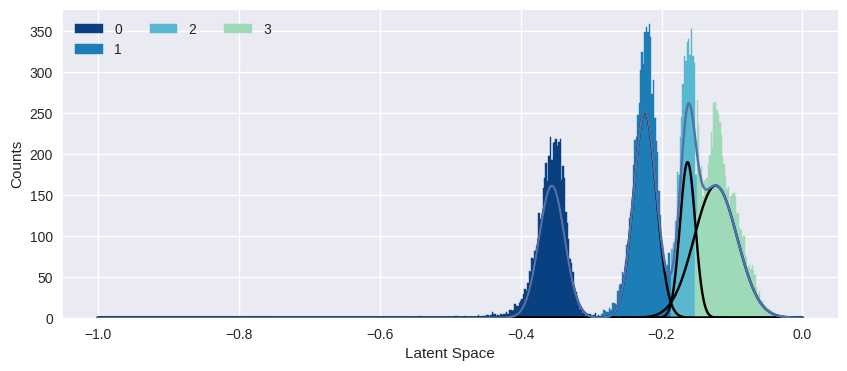

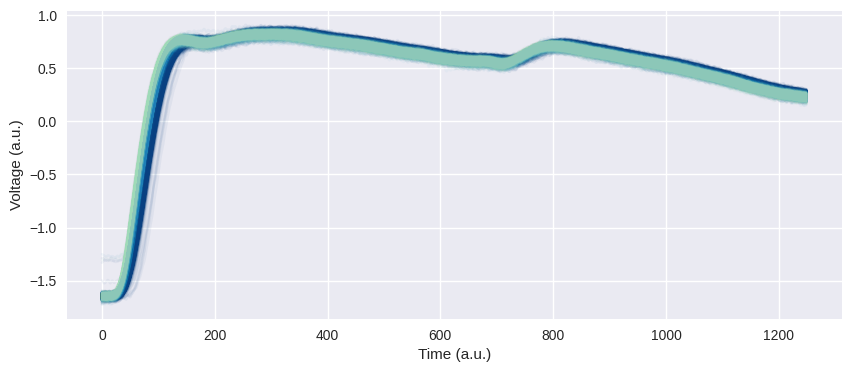

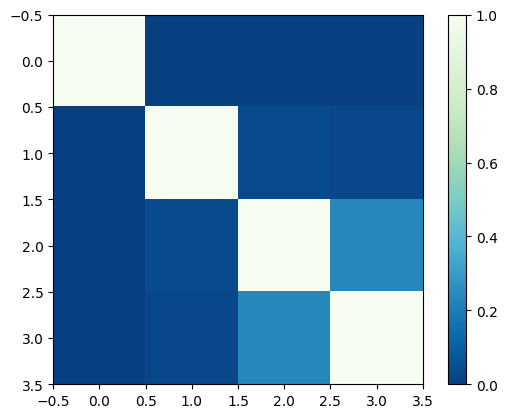

In [27]:
kd = density_gaussianMixture(X_l_KPCA_C, 
                                bw = [0.007],
                                min_cluster_prob = 0.02,
                                bins_plot = 500,
                                flip = True, 
                                skip = 0)
kd.plot_density()
kd.plot_cluster(35)
kd.plot_traces(np.copy(X_test))
kd.plot_cross_talk()
#kd.confidence(zeros)
X_l_KPCA_C = kd.normalize_latent(X_l_KPCA_C, certain_clusters)

### t-distributed Stochastic Neighbor Embedding (t-SNE)

In [28]:
X_i_TSNE, X_l_TSNE = dimension_reduction(np.copy(X_train),np.copy(X_test), path_save,TSNE,n_components=1, perplexity=2000)

'TSNE' object has no attribute 'transform'


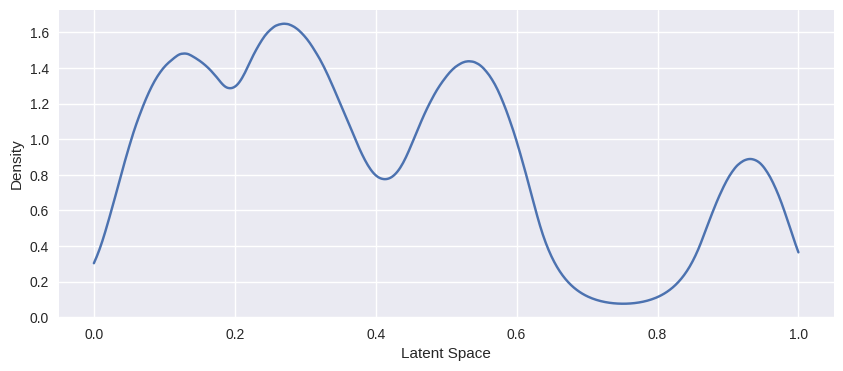

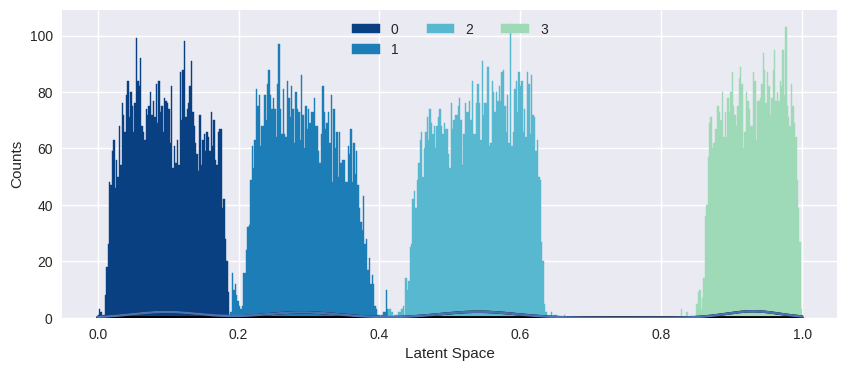

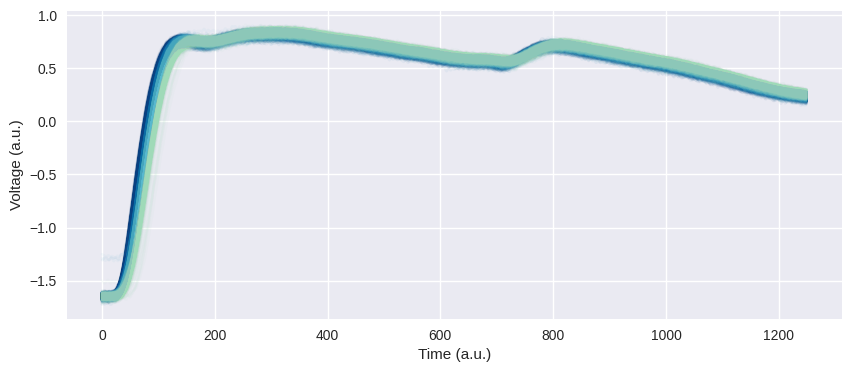

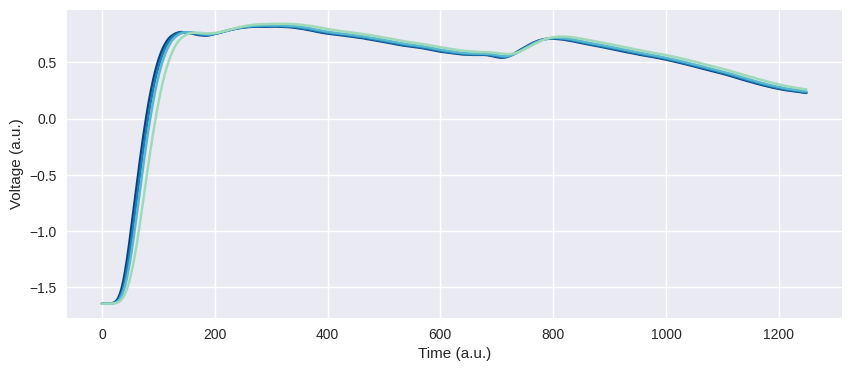

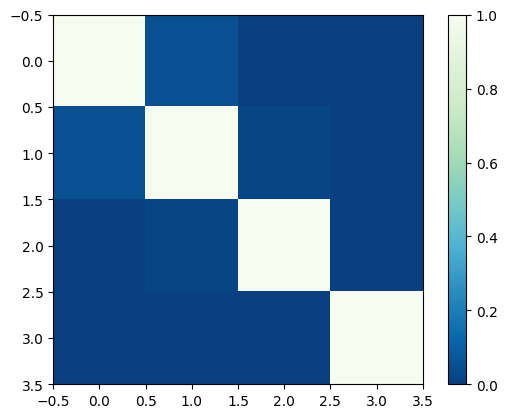

In [29]:
kd = density_gaussianMixture(X_l_TSNE,
                                bw = [0.08],
                                min_cluster_prob = 0.02,
                                density_kernel='exponential',
                                bins_plot = 500,
                                flip = False, 
                                skip = 0)
kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))
kd.plot_traces_average(np.copy(X_test))
kd.plot_cross_talk()
#kd.confidence(zeros)
X_l_TSNE = kd.normalize_latent(X_l_TSNE, certain_clusters)

### Spectral Embedding 

In [30]:
#X_i_SE, X_r_SE, X_l_SE = dimension_reduction(np.copy(X),SpectralEmbedding,n_components=1)
#plot_1D(X_l_SE)

### Non-Negative Matrix Factorization (NMF)

In [31]:
X_i_NMF, X_l_NMF = dimension_reduction(2.1+np.copy(X_train),2.1+np.copy(X_test), path_save,NMF,n_components=1,alpha_W=0.1,random_state=42)

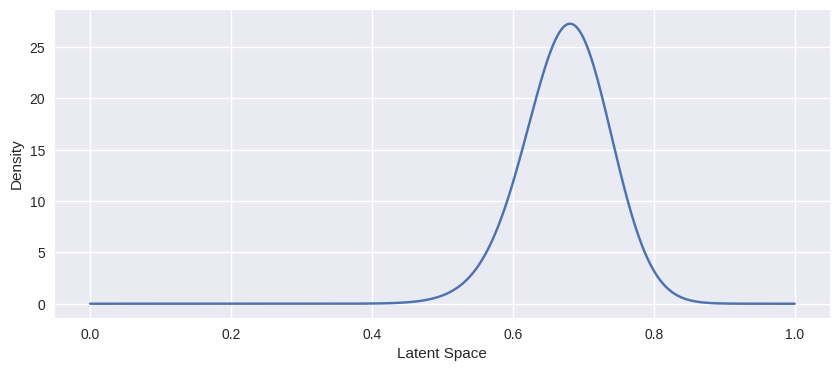

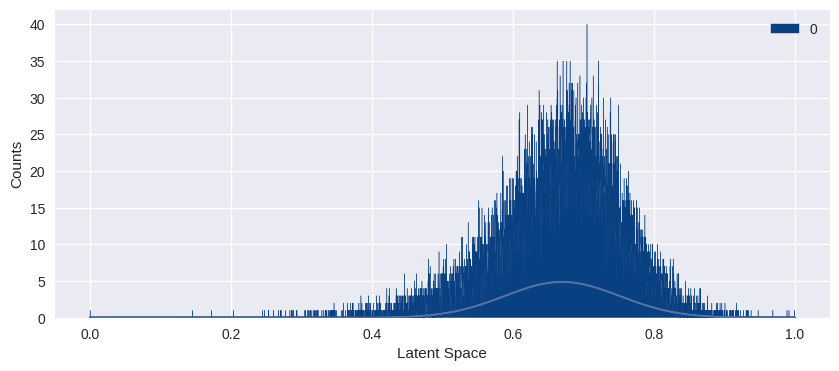

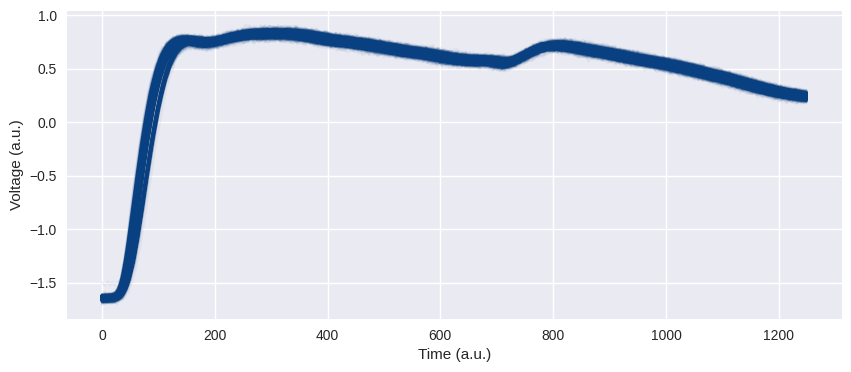

In [32]:
kd = density_gaussianMixture(X_l_NMF, 
                                bw = [0.05],
                                min_cluster_prob = 0.02,
                                bins_plot = 5000,
                                flip = False, 
                                skip = 0)
kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))
X_l_NMF = kd.normalize_latent(X_l_NMF, certain_clusters)

### Isomap

In [33]:
X_i_ISO, X_l_ISO = dimension_reduction(np.copy(X_train),np.copy(X_test), path_save, Isomap,n_neighbors=10, n_components=1, eigen_solver="arpack")

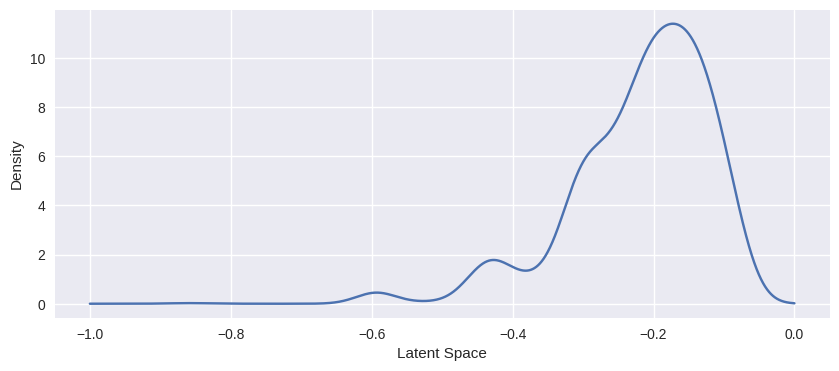

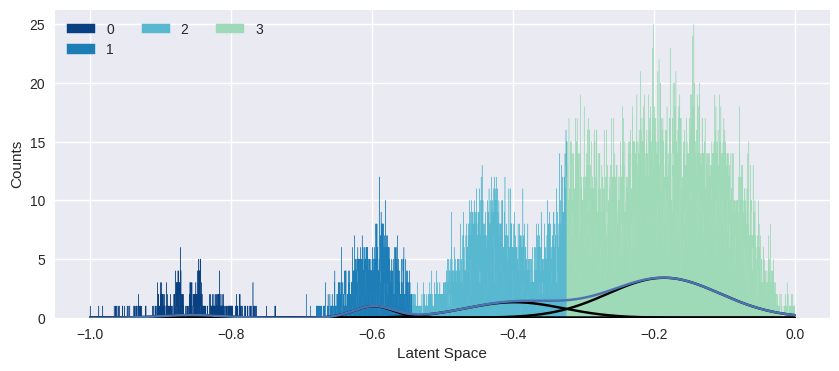

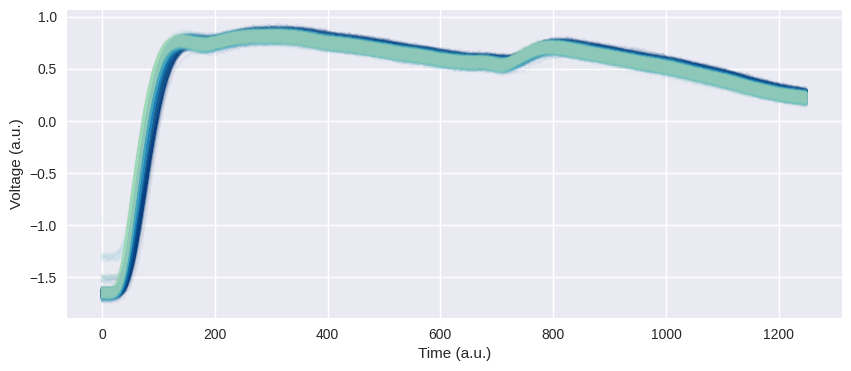

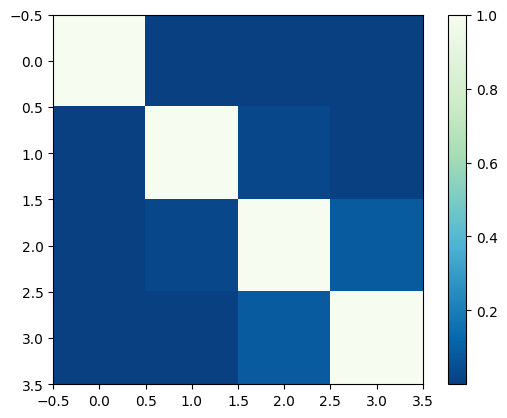

In [ ]:
kd = density_gaussianMixture(X_l_ISO, 
                                bw = [0.03],
                                min_cluster_prob = 0.015, 
                                bins_plot = 5000,
                                flip = True, 
                                skip = 0)
kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))
kd.plot_cross_talk()
X_l_ISO = kd.normalize_latent(X_l_ISO, certain_clusters)

### Autoencoder



In [ ]:
X_i_AUTO, X_r_AUTO, X_l_AUTO  = loadAutoencoder(np.copy(X_test), f'AutoencoderLog/{path_model}', filter=False, flip=True)

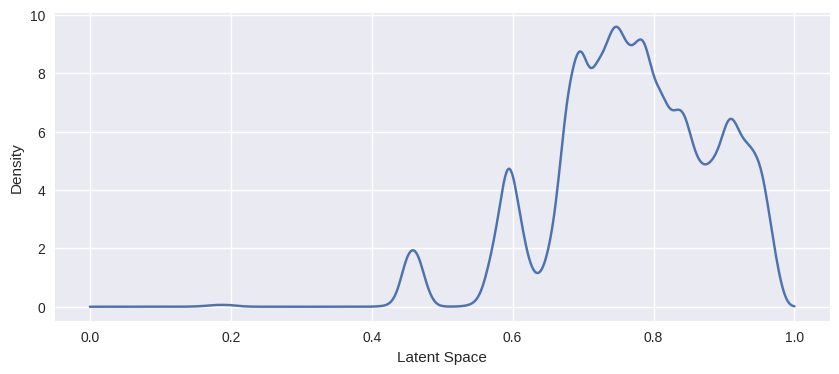

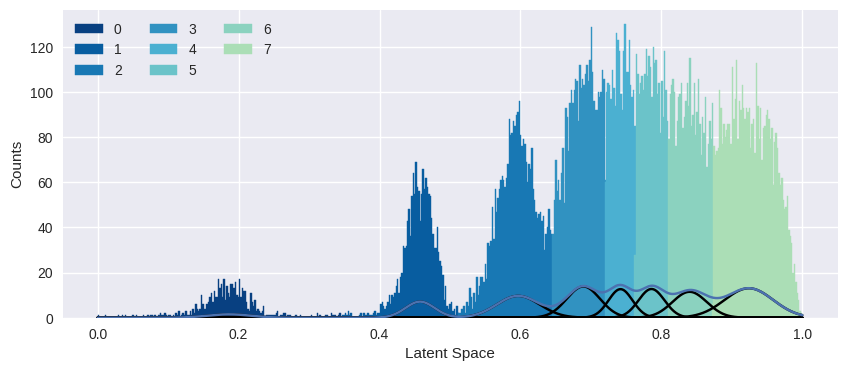

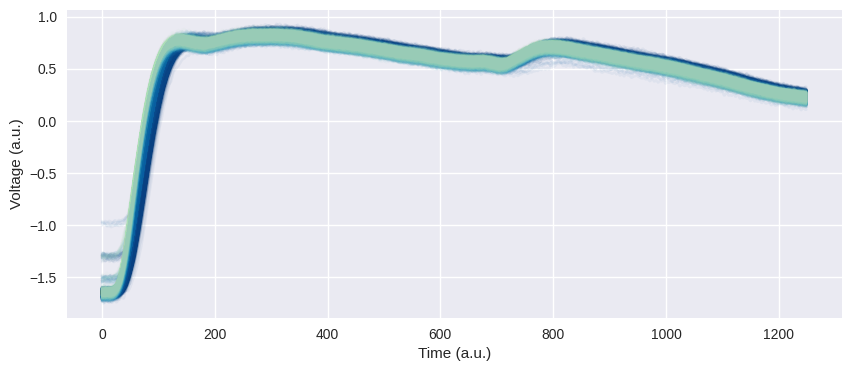

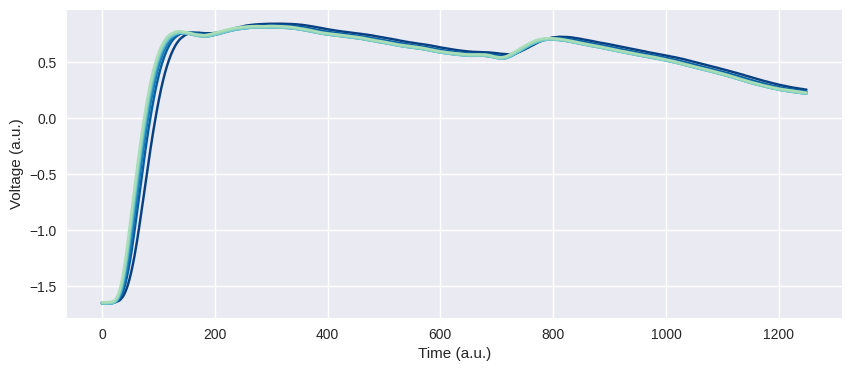

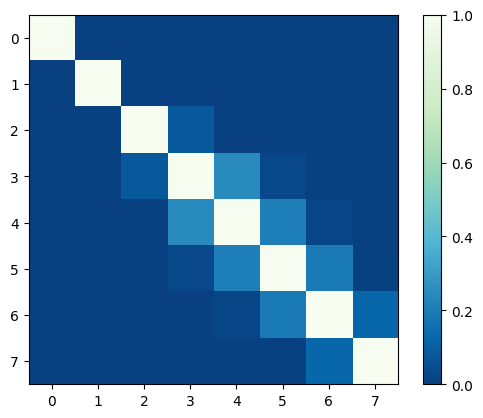

In [ ]:
kd = density_gaussianMixture(X_l_AUTO,
                                bw = [0.009], 
                                min_cluster_prob = 0.02,
                                bins_plot = 500,
                                flip = True, 
                                skip = 0)
kd.plot_density()
kd.plot_cluster(5)
kd.plot_traces(np.copy(X_test))
kd.plot_traces_average(np.copy(X_test))
kd.plot_cross_talk()
X_l_AUTO = kd.normalize_latent(X_l_AUTO, certain_clusters)

In [ ]:
X_i_AUTOF, X_r_AUTOF, X_l_AUTOF = loadAutoencoder(np.copy(X_test), f'AutoencoderLog/{path_model}', 
                                                  filter=True, 
                                                  threshold=0.0005)

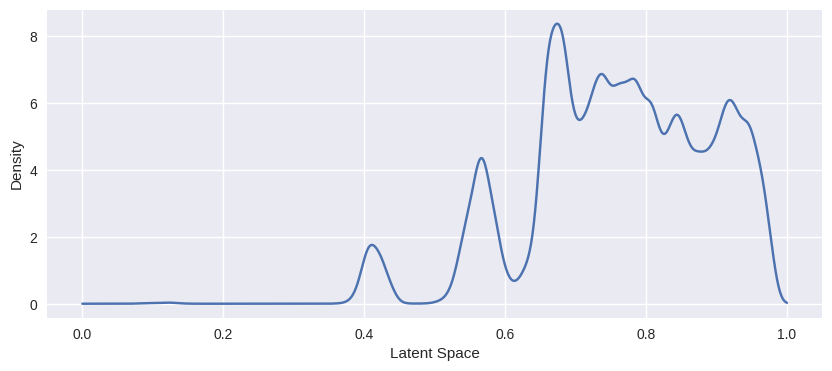

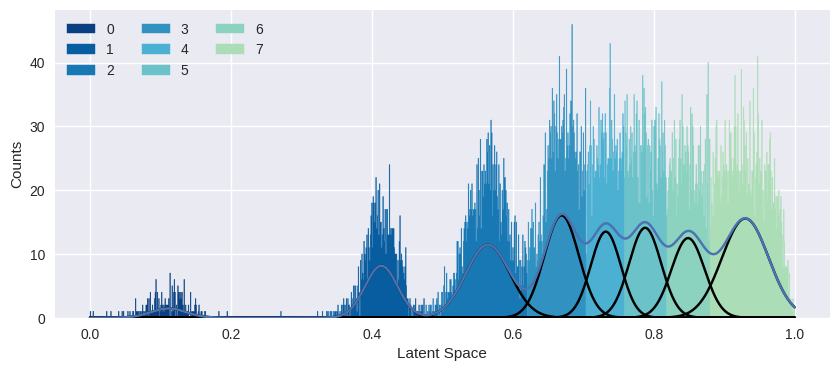

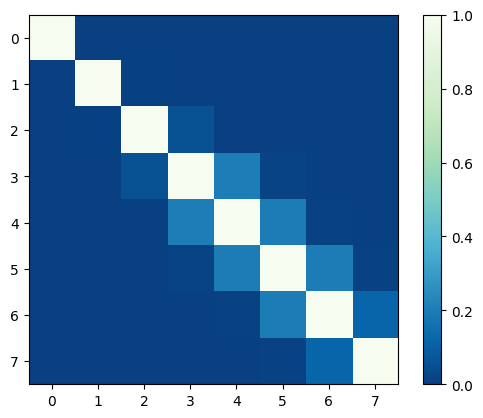

In [ ]:
kd = density_gaussianMixture(X_l_AUTOF, 
                                bw = [0.009], 
                                min_cluster_prob = 0.01,
                                bins_plot = 1000,
                                flip = False, 
                                skip = 0)
kd.plot_density()
kd.plot_cluster(6)
#kd.plot_traces(np.copy(X_test))
kd.plot_cross_talk()
X_l_AUTOF = kd.normalize_latent(X_l_AUTOF, certain_clusters)

In [ ]:
i = [X_i_PCA, X_i_KPCA_P, 
     X_i_KPCA_RBF, X_i_KPCA_C,  
     X_i_TSNE, X_i_ISO, 
     X_i_AUTO, X_i_AUTOF]
l = [X_l_PCA, X_l_KPCA_P, 
     X_l_KPCA_RBF, X_l_KPCA_C,  
     X_l_TSNE, X_l_ISO, 
     X_l_AUTO, X_l_AUTOF]
methods = ['PCA', 'K-PCA (Polynomial)', 
           'K-PCA (RBF)', 'K-PCA (Cosine)', 
           't-SNE', 'Isomap',
           'Autoencoder', 'Autoencoder\nFiltered']
flip = [True, True, 
        True, True, 
        True, True, 
        False, True]
density_kernel = ['gaussian', 'gaussian', 
                  'gaussian', 'gaussian',  
                  'exponential', 'gaussian',
                  'gaussian', 'gaussian']
min_cluster_prob = [0.04, 0.04, 
                    0.04, 0.04,
                    0.04, 0.04, 
                    0.04, 0.04]
bw = [0.03, 0.024, 
      0.016, 0.018,
      0.03, 0.03, 
      0.018, 0.015]

comp = compare(flip, min_cluster_prob, density_kernel, bw)
#score = comp.quality_metric_plot(i,l,methods, 4)